In [27]:
import numpy as np
import matplotlib.pyplot as plt

In [28]:
#synthetic data
X_train = np.array([1, 2, 1.3, 2.5, 1.7, 1.1, 2.2] )  #hourse size in 1000 square feet
y_train = np.array([300, 500, 350, 610, 420, 310, 550])  #house price in 1000 dollars

In [29]:
print(X_train.shape)

(7,)


To make a model that fits a linear function to this, we must first have the function. Which is `f(x) = wx + b`
Then we need cost function that calculates the error of a prediction made using that function. That cost function can be:
$$J(w,b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2\tag{2}$$ 
After we do that, we need to calculate the gradient for this loss function relative to w and again relative to b. The calculation is:$$
\begin{align}
\frac{\partial J(w,b)}{\partial w}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})x^{(i)} \tag{4}\\
  \frac{\partial J(w,b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)}) \tag{5}\\
\end{align}
$$
Then last step is to apply this gradient in a gradient decent algorithm to keep applying the previous steps repeatidly and fixing the error each iteration based on opposite of the gradient we calculated. The algorithm looks like this:
$$\begin{align*} \text{repeat}&\text{ until convergence:} \; \lbrace \newline
\;  w &= w -  \alpha \frac{\partial J(w,b)}{\partial w} \tag{3}  \; \newline 
 b &= b -  \alpha \frac{\partial J(w,b)}{\partial b}  \newline \rbrace
\end{align*}$$

In [30]:
#linear_function
def linear_regression(x, w, b):
    f_wb = (w * x) + b
    return f_wb

In [31]:
#compute cost
def cost(x, w, b, y):
    # we pass x,w,b so we can call linear_regression()
    # we also passed y to compare between prediction and true target
    # x, y -> type: np.array
    m = x.shape[0] #size of training set
    cost = 0
    for i in range(m):
        y_hat = linear_regression(x[i], w, b)
        cost += (y_hat - y[i])**2
    total_cost = (1/(2*m)) * cost
    return total_cost


In [32]:
#compute gradient
def gradient(x, w, b, y):
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0
    for i in range(m):
        y_hat = linear_regression(x[i], w, b)
        dj_dw_i = (y_hat - y[i]) * x[i]
        dj_db_i = (y_hat - y[i])
        dj_dw += dj_dw_i
        dj_db += dj_db_i
    dj_dw = dj_dw / m
    dj_db = dj_db / m
    
    return dj_dw, dj_db

In [33]:
# perform gradient decent
def gradient_decent(x, w_initial, b_initial, y, alpha, num_iterations, cost_function, gradient_function):
    #alpha is learning rate
    cost_history = []
    parameters_history = []
    w = w_initial
    b = b_initial

    for i in range(num_iterations):
        dj_dw, dj_db = gradient_function(x, w, b, y)
        
        w = w - (alpha * dj_dw)
        b = b - (alpha * dj_db)

        cost_history.append(cost_function(x, w, b, y))
        parameters_history.append([w, b])
    return w, b, cost_history, parameters_history

In [34]:
w_init = 0
b_init = 0
num_of_iterations = 10000
learning_rate = 0.01
w_final, b_final, cost_history, parameter_history = gradient_decent(X_train, w_init, b_init, y_train, learning_rate, num_of_iterations, cost, gradient)
print(f"final parameters: {w_final:.2f} & {b_final:.2f}")

final parameters: 211.41 & 77.91


What does this output mean?
It means that the our linear function that maps a house's size to it's price (according to this dataset) is:
$$f(x) = 211.41x + 77.91$$

In [35]:
#prediction
x_new = 1.5 #1500 square feet
prediction = (211.41 * x_new) + 77.91
print(f"House is predicted to cost: {prediction:.2f}k")

House is predicted to cost: 395.02k


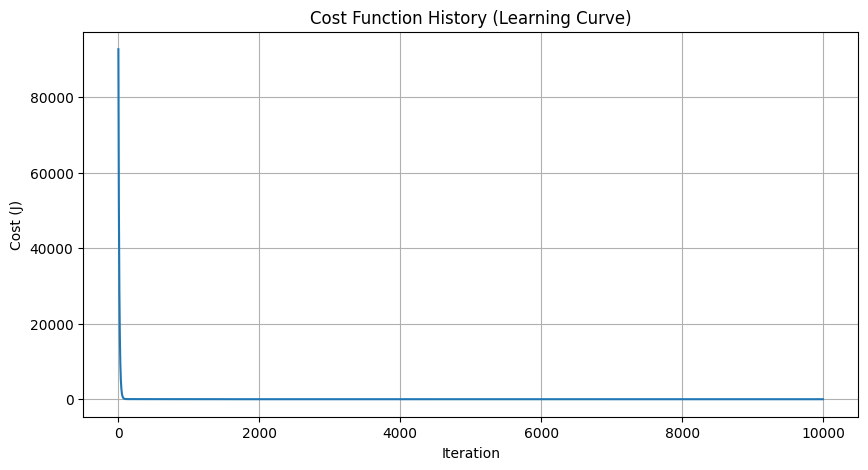

In [36]:
# Plotting the Cost History
plt.figure(figsize=(10, 5))
plt.plot(cost_history)
plt.title("Cost Function History (Learning Curve)")
plt.xlabel("Iteration")
# In ML, we want to see this drop sharply and then flatten out (plateau)
plt.ylabel("Cost (J)") 
plt.grid(True)
plt.show()

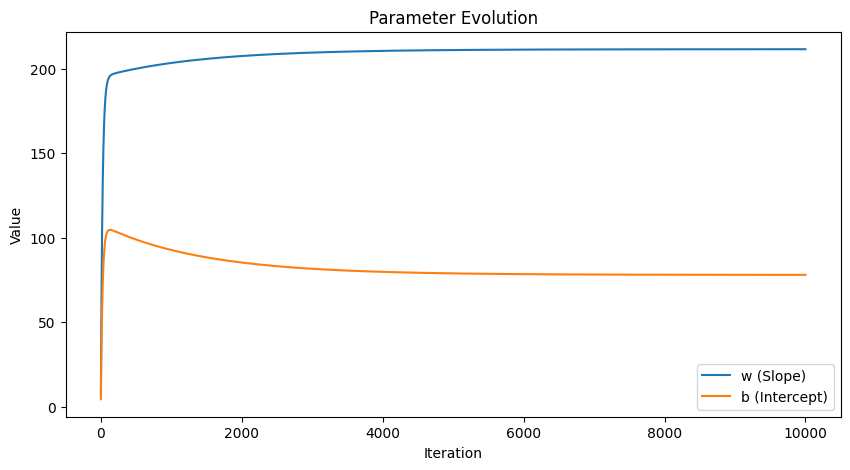

In [38]:
# Plotting the Parameter History (The "Path")
w_vals = [p[0] for p in parameter_history]
b_vals = [p[1] for p in parameter_history]

plt.figure(figsize=(10, 5))
plt.plot(w_vals, label='w (Slope)')
plt.plot(b_vals, label='b (Intercept)')
plt.title("Parameter Evolution")
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.legend()
plt.show()